In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
tmdb = pd.read_csv("../datasets/raw/tmdb-movies/TMDB_movie_dataset_v11.csv")
KEEP = [
    "id",
    "title",
    "overview",
    "genres",
    "keywords",
    "vote_average",
    "vote_count",
    "popularity",
    "release_date"
]
tmdb = tmdb[KEEP]
tmdb = tmdb[tmdb["vote_count"] > 30]
tmdb["overview"] = tmdb["overview"].fillna("")
tmdb["genres"] = tmdb["genres"].fillna("")
tmdb["keywords"] = tmdb["keywords"].fillna("")
tmdb.head()

,id,title,overview,genres,keywords,vote_average,vote_count,popularity,release_date
0,27205,Inception,"Cobb, a skilled thief who commits corporate es...","Action, Science Fiction, Adventure","rescue, mission, dream, airplane, paris, franc...",8.364,34495,83.952,2010-07-15
1,157336,Interstellar,The adventures of a group of explorers who mak...,"Adventure, Drama, Science Fiction","rescue, future, spacecraft, race against time,...",8.417,32571,140.241,2014-11-05
2,155,The Dark Knight,Batman raises the stakes in his war on crime. ...,"Drama, Action, Crime, Thriller","joker, sadism, chaos, secret identity, crime f...",8.512,30619,130.643,2008-07-16
3,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","Action, Adventure, Fantasy, Science Fiction","future, society, culture clash, space travel, ...",7.573,29815,79.932,2009-12-15
4,24428,The Avengers,When an unexpected enemy emerges and threatens...,"Science Fiction, Action, Adventure","new york city, superhero, shield, based on com...",7.710,29166,98.082,2012-04-25


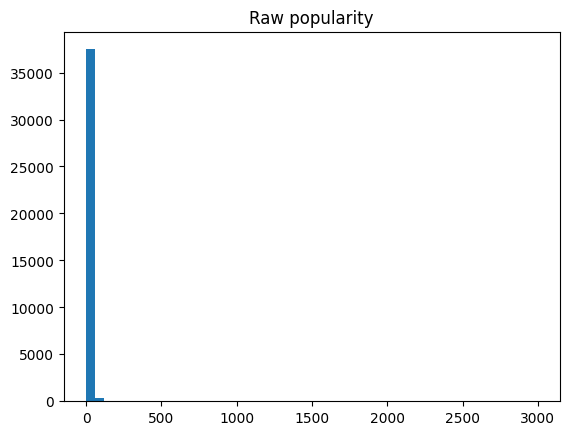

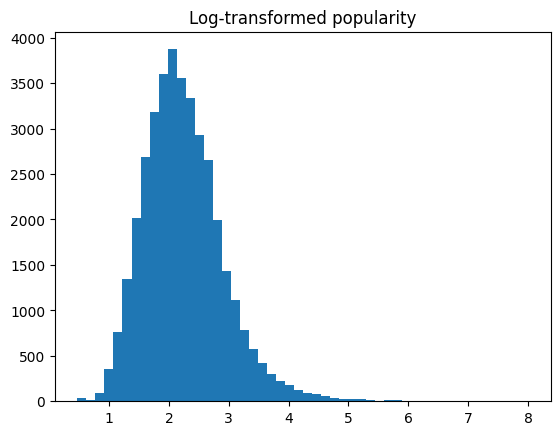

In [5]:
plt.hist(tmdb["popularity"], bins=50)
plt.title("Raw popularity")
plt.show()

plt.hist(np.log1p(tmdb["popularity"]), bins=50)
plt.title("Log-transformed popularity")
plt.show()

In [8]:
tmdb["popularity_log"] = np.log1p(tmdb["popularity"])
tmdb["content"] = tmdb["overview"] + " " + tmdb["genres"] + " " + tmdb["keywords"]

In [9]:
tmdb.info()

<class 'pandas.DataFrame'>
RangeIndex: 37972 entries, 0 to 37971
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              37972 non-null  int64  
 1   title           37972 non-null  str    
 2   overview        37972 non-null  str    
 3   genres          37972 non-null  str    
 4   keywords        37972 non-null  str    
 5   vote_average    37972 non-null  float64
 6   vote_count      37972 non-null  int64  
 7   popularity      37972 non-null  float64
 8   release_date    37965 non-null  str    
 9   popularity_log  37972 non-null  float64
 10  content         37972 non-null  str    
dtypes: float64(3), int64(2), str(6)
memory usage: 3.2 MB


In [10]:
movie_lens_links = pd.read_csv("../datasets/raw/ml-32m/links.csv")

movie_lens_links = movie_lens_links.dropna(subset=["tmdbId"])
movie_lens_links["tmdbId"] = movie_lens_links["tmdbId"].astype("int64")
movie_lens_links.head()

,movieId,imdbId,tmdbId
0,1,114709,862
1,2,113497,8844
2,3,113228,15602
3,4,114885,31357
4,5,113041,11862


In [11]:
movie_lens_ratings = pd.read_csv("../datasets/raw/ml-32m/ratings.csv")
ratings = pd.merge(
    movie_lens_ratings[['userId', 'rating', 'movieId']],
    movie_lens_links[['movieId', 'tmdbId']],
    on='movieId',
    how='left'
)
ratings = ratings[ratings["tmdbId"].notna()]
ratings["tmdbId"] = ratings["tmdbId"].astype("int64")

min_user_ratings = 5
min_movie_ratings = 5

user_counts = ratings.groupby('userId').size()
movie_counts = ratings.groupby('tmdbId').size()

rating = ratings[
    ratings['userId'].isin(user_counts[user_counts >= min_user_ratings].index) &
    ratings['tmdbId'].isin(movie_counts[movie_counts >= min_movie_ratings].index)
]
ratings.head()

,userId,rating,movieId,tmdbId
0,1,4.0,17,4584
1,1,1.0,25,451
2,1,2.0,29,902
3,1,5.0,30,37557
4,1,5.0,32,63


In [12]:
ratings.info()

<class 'pandas.DataFrame'>
Index: 31995478 entries, 0 to 32000203
Data columns (total 4 columns):
 #   Column   Dtype  
---  ------   -----  
 0   userId   int64  
 1   rating   float64
 2   movieId  int64  
 3   tmdbId   int64  
dtypes: float64(1), int64(3)
memory usage: 1.2 GB
